# DA5400W: Assignment 3 — Customer Lifetime Value Prediction
### PCA + K-Means Clustering + Linear Regression Pipeline

**Course:** DA5400W — Foundations of Machine Learning  
**Instructor:** Dr. Arun B Ayyar, IIT Madras  
**Student Name:** ___________________________  
**Roll Number:** ___________________________  

---

### Background

You are a data scientist at an e-commerce company. The goal is to understand customer behaviour and **predict Customer Lifetime Value (CLV)** — the total revenue a customer is expected to generate.

You are given a dataset of **800 customers** with 8 behavioural features:

| Feature | Description |
|---|---|
| `recency_days` | Days since the customer's last purchase |
| `purchase_frequency` | Number of purchases in the last 12 months |
| `avg_basket_size_gbp` | Average order value (GBP) |
| `num_categories` | Number of distinct product categories purchased |
| `return_rate` | Fraction of orders returned |
| `discount_sensitivity` | Fraction of purchases made with a discount |
| `email_open_rate` | Fraction of marketing emails opened |
| `tenure_months` | Months since the customer registered |

**Target:** `clv_gbp` — estimated Customer Lifetime Value in GBP.

### Marks

| Section | Topic | Marks |
|---|---|---|
| Q1 | PCA — Dimensionality Reduction | 3 |
| Q2 | K-Means Clustering — Customer Segmentation | 3 |
| Q3 | Linear Regression — CLV Prediction | 3 |
| Q4 | Analysis — Interpretation | 1 |
| **Total** | | **10** |

> **Instructions:** Write your code in the empty cells. Do not modify the setup cell. Submit this notebook with all cells executed and outputs visible.


## Setup — Run this cell first, do not modify


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('customer_data.csv')
features = ['recency_days', 'purchase_frequency', 'avg_basket_size_gbp',
            'num_categories', 'return_rate', 'discount_sensitivity',
            'email_open_rate', 'tenure_months']
X_raw = df[features].copy()
y = df['clv_gbp'].copy()
print(f'Dataset: {df.shape[0]} customers, {len(features)} features')
df[features + ['clv_gbp']].describe().round(2)


Dataset: 800 customers, 8 features


,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months,clv_gbp
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,73.83,11.78,61.22,3.39,0.13,0.40,0.23,14.19,364.16
std,72.81,8.70,49.72,2.19,0.08,0.24,0.17,11.59,905.49
min,1.00,1.00,5.00,1.00,0.00,0.00,0.00,1.00,5.00
25%,26.67,2.00,29.55,2.00,0.08,0.21,0.09,5.00,6.24
50%,44.57,11.00,48.76,3.00,0.12,0.35,0.22,12.00,51.31
75%,88.93,18.00,73.65,4.00,0.19,0.60,0.33,21.00,176.82
max,334.78,40.00,279.78,12.00,0.36,1.00,0.76,60.00,5000.00


In [ ]:
X = df.drop('clv_gbp',axis=1)
y = df['clv_gbp']

In [ ]:
#X,y

---
## Q1: PCA — Dimensionality Reduction (3 marks)

**[1 mark]** Standardise the 8 features using `StandardScaler`. Fit a full PCA and plot the **scree plot** (variance per component) and **cumulative explained variance**. State how many components explain at least 80% of the variance.

**[1 mark]** Reduce the data to that number of components (store as `X_pca`). Also create a **2D projection** (PC1 vs PC2) and colour the scatter plot by CLV.

**[1 mark]** Plot the **loadings** of PC1 and PC2. In one sentence each, state what customer characteristic each component captures.




no. of component for 80% variance : 3


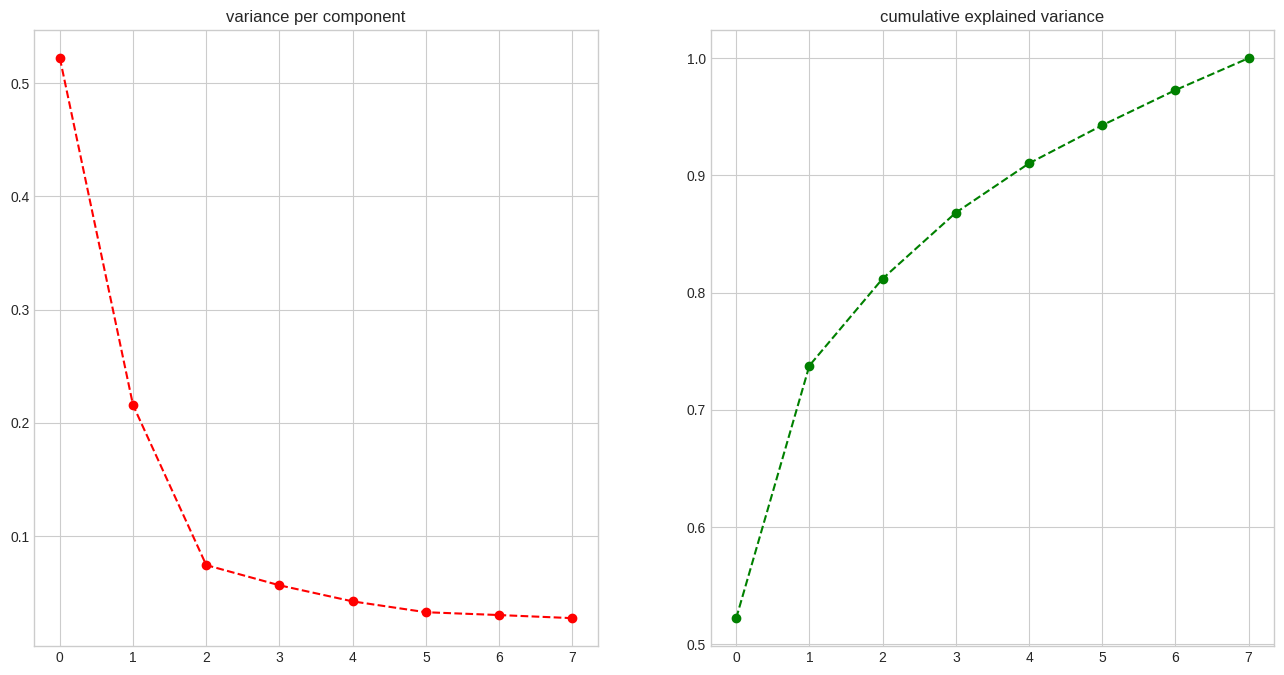

In [ ]:
# Q1 Part 1: Standardise features, fit PCA, plot scree + cumulative variance
# Store: X_scaled, n_components

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# pca
pca = PCA()
X_scaled_pca = pca.fit_transform(X_scaled)

#  scree plot
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(16,8))
var_comp = axes[0].plot(pca.explained_variance_ratio_,marker='o', linestyle='dashed',color='red')
axes[0].set_title("variance per component")
cum_sum_plot = axes[1].plot(np.cumsum(pca.explained_variance_ratio_),marker='o',linestyle='dashed',color='green')
axes[1].set_title("cumulative explained variance")

# components explain at least 80% of the variance
cum_sum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cum_sum_var>=0.8)+1

n_components = n_components_80
print(f"no. of component for 80% variance : {n_components_80}")

In [ ]:
# Q1 Part 2: Reduce to n_components (store as X_pca)
# Also create 2D projection (store as X_pca_2d) and scatter plot coloured by CLV

# pca
pca = PCA(n_components =2)
X_scaled_pca = pca.fit_transform(X_scaled)

In [ ]:
# Q1 Part 3: Plot PC1 and PC2 loadings as bar charts
# Print one-sentence interpretation for each component
pca_compoenet_df = pd.DataFrame(pca.components_,columns =features,index=['PC1','PC2'] )
pca_compoenet_df

,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months
PC1,-0.318620,0.331766,0.348322,0.438191,-0.253610,-0.238238,0.427776,0.413529
PC2,-0.453422,0.453178,-0.318663,0.063185,0.406159,0.562747,0.032365,0.028343


---
## Q2: K-Means Clustering — Customer Segmentation (3 marks)

**[1 mark]** Run K-Means for k = 2 to 10. Plot the **elbow plot** (inertia vs k) and the **silhouette score** vs k side by side. Based on both plots, choose the best k and justify your choice in a print statement.

**[1 mark]** Fit K-Means with your chosen k on the PCA-reduced data (`X_pca`). Visualise the clusters in the PC1-PC2 space, marking each cluster's centroid with a star.

**[1 mark]** For each cluster, compute the **mean of each original feature**. Print the summary table and write one sentence describing what type of customer each cluster represents.




number of cluster : 4 , becuase at elblow start's plataeu i.e. WCSS get's minimum post that it's coming very less change in error and shilutte achieved hightest score. 



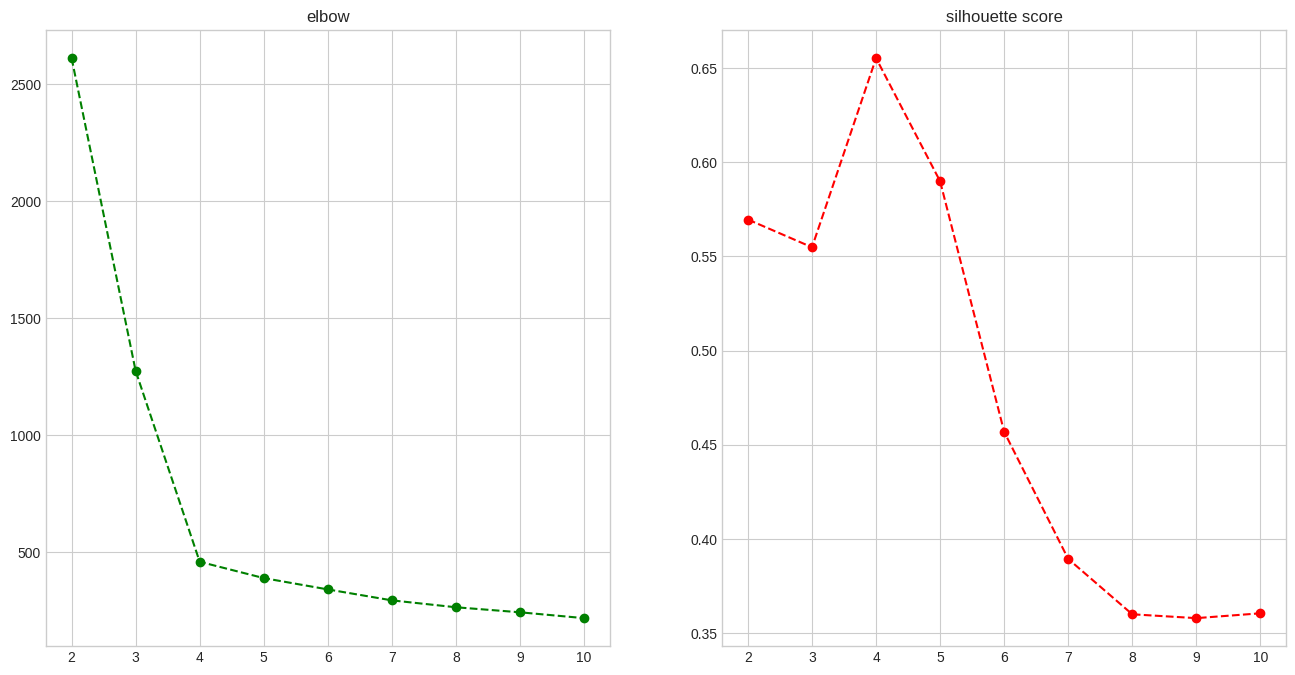

In [ ]:
# Q2 Part 1: Elbow plot and silhouette score for k = 2 to 10
# Store: best_k (your chosen number of clusters)
interia = []
shilutte_score = []
c_range = range(2,11)

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=5,random_state=42)
    kmeans.fit(X_scaled_pca)
    interia.append(kmeans.inertia_)
    shilutte_score.append(silhouette_score(X=X_scaled_pca, labels = kmeans.labels_))


fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(16,8))
elbow_plot = axes[0].plot(c_range,interia,marker ='o',linestyle='dashed',color='green')
axes[0].set_title("elbow")

sil_plot = axes[1].plot(c_range,shilutte_score,marker ='o',linestyle='dashed',color='red')
axes[1].set_title("silhouette score")

print(f"number of cluster : 4 , becuase at elblow start's plataeu i.e. WCSS get's minimum post that it's coming very less change in error and shilutte achieved hightest score. \n")

Text(0.5, 1.0, 'clusters in the PC1-PC2 space')

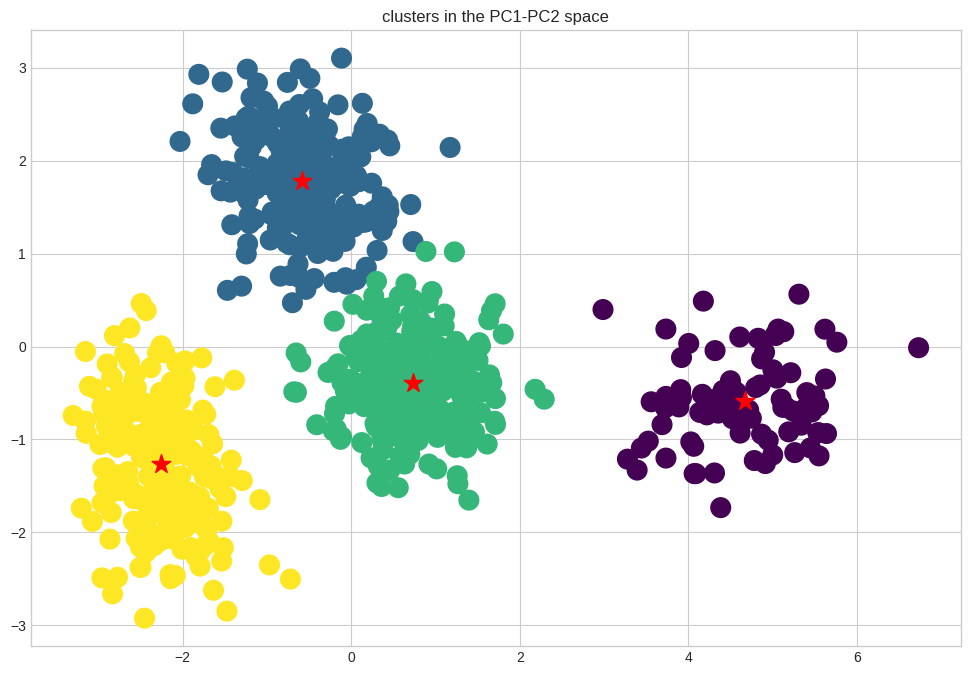

In [ ]:
# Q2 Part 2: Fit K-Means with best_k, visualise clusters in PC1-PC2 space
# Store: labels (cluster assignments for all 800 customers)

kmeans = KMeans(n_clusters=4, init='k-means++', n_init=5,random_state=42)
kmeans.fit(X_scaled_pca)
labels = kmeans.labels_
centroid = kmeans.cluster_centers_

# visualization
fig= plt.figure(figsize = (12,8))
plt.scatter(X_scaled_pca[:,0],X_scaled_pca[:,1],c=labels,cmap='viridis',s=200)
plt.scatter(centroid[:,0],centroid[:,1],marker = '*',s=200,color='red')
plt.title('clusters in the PC1-PC2 space')

In [ ]:
# Q2 Part 3: Mean feature values per cluster — print summary table
# Write one-sentence description for each cluster
df_with_cluster_level = X_raw.copy()
df_with_cluster_level['cluster'] = labels
df_with_cluster_level_summary = df_with_cluster_level.groupby('cluster').mean()
display(df_with_cluster_level_summary)
print("cluster 1: having recent perchase and avg basket size is also high and frequently open the mail.")
print("cluster 2: recent perchase is approx month  and avg basket size is also low  but very sensitive  on discount")
print("cluster 3: recent perchase is approx 45 days  and avg basket size is avg  but moderlate mail open rate")
print("cluster 4: recent perchase is approx 6 months .")

,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months
cluster,,,,,,,,
0,14.693304,25.223529,179.276235,7.929412,0.048282,0.098788,0.548176,36.058824
1,31.852638,17.794872,25.443761,3.064103,0.191513,0.703889,0.191197,11.589744
2,46.910730,10.400722,60.525848,3.945848,0.099350,0.249740,0.296412,17.761733
3,183.159006,1.142157,54.012500,1.127451,0.150255,0.386961,0.054951,3.215686


---
## Q3: Linear Regression — CLV Prediction (3 marks)

**[1 mark]** Split the data 80/20 (train/test, `random_state=42`). Train a `LinearRegression` model on the **raw 8 features** (baseline). Report RMSE and R-squared on the test set.

**[1 mark]** Build a combined feature matrix: **PCA components + one-hot cluster labels**. Train a second `LinearRegression` on this matrix. Report RMSE and R-squared.

**[1 mark]** Plot **predicted vs actual CLV** for both models side by side. Comment on which model performs better.

---
**Hints:**
- `train_test_split(X_raw, y, test_size=0.2, random_state=42)` to split the data
- On the predicted vs actual plot, add a red dashed diagonal (`y = x`) as the perfect prediction line


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error,r2_score
# import numpy as np

# # splitting and training
# X_train,X_test,y_train,y_test = train_test_split(X_raw,y,test_size=0.2,random_state=42)
# linear_model = LinearRegression()
# linear_model.fit(X_train,y_train)
# y_pred = linear_model.predict(X_test)

# # metrics
# RMSE = np.sqrt(mean_squared_error(y_test,y_pred))
# r2_squared  = r2_score(y_test,y_pred)

# print(RMSE,r2_squared)

In [ ]:
# Q3 Part 1: Baseline Linear Regression on raw features
# Store: X_train, X_test, y_train, y_test
# Print: RMSE and R2

# splitting and model training
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)
lin_model1 = LinearRegression()
lin_model1.fit(X_train,y_train)
y_pred = lin_model1.predict(X_test)

# model evaluation
mean_squared_error1 = np.sqrt(mean_squared_error(y_test,y_pred))
r2_score1 = r2_score(y_test,y_pred)

print(f"mean_squared_error : {round(mean_squared_error1,2)}")
print(f"r2_score : {round(r2_score1,2)}")

mean_squared_error : 324.34
r2_score : 0.85


In [ ]:
# Q3 Part 2: Linear Regression on PCA + cluster features
# Print: RMSE and R2

#X_scaled_pca
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder(sparse_output=False)
X_cluster_labels = one_hot.fit_transform(labels.reshape(-1,1))

#PCA + cluster features
X_raw_pca_cluster = np.hstack((X_scaled_pca,X_cluster_labels))

#model
X_train1,X_test1,y_train1,y_test1 = train_test_split(X_raw_pca_cluster,y,test_size=0.2,random_state=42)

linear_model2 = LinearRegression()
linear_model2.fit(X_train1,y_train1)

y_pred_new = linear_model2.predict(X_test1)

# model evaluation
mean_squared_error2 = np.sqrt(mean_squared_error(y_test,y_pred_new))
r2_score2 = r2_score(y_test,y_pred_new)

print(f"mean_squared_error : {round(mean_squared_error2,2)}")
print(f"r2_score : {round(r2_score2,2)}")

mean_squared_error : 266.38
r2_score : 0.9


In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.model_selection import train_test_split
# encoder = OneHotEncoder(spare_output=False)
# X_cluster_labels = endcoder.fit_transform(labels.reshape(-1,1))
# X_raw_pca_cluster = np.hstack((X_scaled_pca,X_cluster_labels))

# #train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X_raw_pca_cluster,y, test_size = 0.2,random_state=42)


Text(0, 0.5, 'Actual CLV')

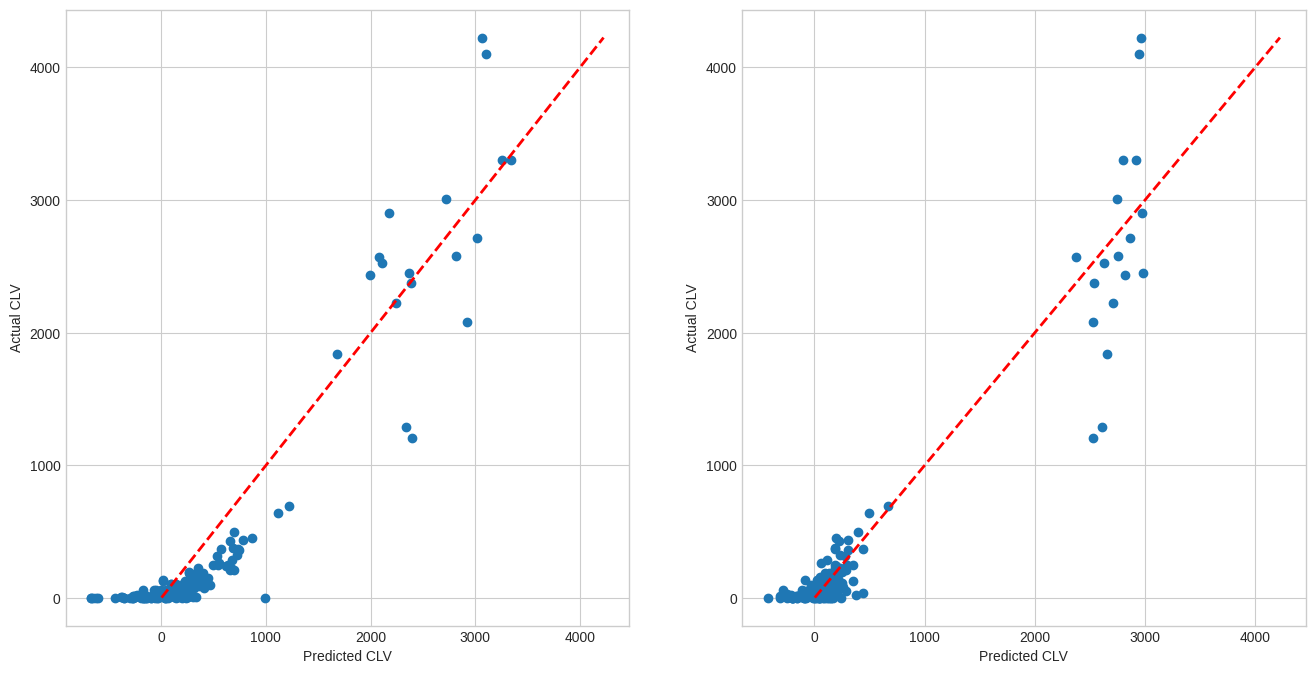

In [ ]:
# Q3 Part 3: Predicted vs Actual CLV — both models side by side

# model 1 :Predicted vs Actual CLV
fig,axes= plt.subplots(nrows=1,ncols=2,figsize=(16,8))
model1_visual = axes[0].scatter(y_pred,y_test)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Predicted CLV")
axes[0].set_ylabel("Actual CLV")

# model 2 :Predicted vs Actual CLV
model1_visual = axes[1].scatter(y_pred_new,y_test)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel("Predicted CLV")
axes[1].set_ylabel("Actual CLV")

---
## Q4: Analysis (1 mark)

Answer **both** parts below in the markdown cell provided (2–4 sentences each).

**(a)** The elbow plot and silhouette score sometimes suggest different values of k. Explain what each metric measures and how you would decide between them when they disagree.

**(b)** Adding cluster labels as features improved R-squared compared to the baseline. Explain **why** knowing a customer's segment helps a linear regression model predict CLV more accurately.


### Your Answer to Q4

**(a)** *(Write your answer here)*

**elbow plot :** It is a plot of  WCSS(within cluster sum of square errors) i.e. also called interia at different cluster size. The plot where plateau start i.e. number of cluster for a given dataset.

**silhouette score:** : It measures how well data points clustered. so we will try to pickup the kmeans where interia drops significantly and corresponding silhouette is also balanced not much very low.

**(b)** *(Write your answer here)*
Yes , but singnificantly there has been a slight improvement.

